In [6]:
import pandas as pd

df = pd.read_csv(r"C:\data\metadata_compiled.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34434 entries, 0 to 34433
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             34434 non-null  int64  
 1   uuid                   34434 non-null  object 
 2   datetime               34434 non-null  object 
 3   cough_detected         34434 non-null  float64
 4   latitude               19431 non-null  float64
 5   longitude              19431 non-null  float64
 6   age                    19396 non-null  float64
 7   gender                 20664 non-null  object 
 8   respiratory_condition  20664 non-null  object 
 9   fever_muscle_pain      20664 non-null  object 
 10  status                 20664 non-null  object 
 11  status_SSL             8331 non-null   object 
 12  quality_1              820 non-null    object 
 13  cough_type_1           820 non-null    object 
 14  dyspnea_1              820 non-null    object 
 15  wh

In [7]:
df.head()

,Unnamed: 0,uuid,datetime,cough_detected,latitude,longitude,age,gender,respiratory_condition,fever_muscle_pain,...,quality_4,cough_type_4,dyspnea_4,wheezing_4,stridor_4,choking_4,congestion_4,nothing_4,diagnosis_4,severity_4
0,0,00014dcc-0f06-4c27-8c7b-737b18a2cf4c,2020-11-25T18:58:50.488301+00:00,0.0155,48.9,2.4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,00039425-7f3a-42aa-ac13-834aaa2b6b92,2020-04-13T21:30:59.801831+00:00,0.9609,31.3,34.8,15.0,male,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0007c6f1-5441-40e6-9aaf-a761d8f2da3b,2020-10-18T15:38:38.205870+00:00,0.1643,NaN,NaN,46.0,female,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,00098cdb-4da1-4aa7-825a-4f1b9abc214b,2021-01-22T22:08:06.742577+00:00,0.1133,47.4,9.4,66.0,female,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0009eb28-d8be-4dc1-92bb-907e53bc5c7a,2020-04-12T04:02:18.159383+00:00,0.9301,40.0,-75.1,34.0,male,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.columns.tolist()

['Unnamed: 0',
 'uuid',
 'datetime',
 'cough_detected',
 'latitude',
 'longitude',
 'age',
 'gender',
 'respiratory_condition',
 'fever_muscle_pain',
 'status',
 'status_SSL',
 'quality_1',
 'cough_type_1',
 'dyspnea_1',
 'wheezing_1',
 'stridor_1',
 'choking_1',
 'congestion_1',
 'nothing_1',
 'diagnosis_1',
 'severity_1',
 'quality_2',
 'cough_type_2',
 'dyspnea_2',
 'wheezing_2',
 'stridor_2',
 'choking_2',
 'congestion_2',
 'nothing_2',
 'diagnosis_2',
 'severity_2',
 'quality_3',
 'cough_type_3',
 'dyspnea_3',
 'wheezing_3',
 'stridor_3',
 'choking_3',
 'congestion_3',
 'nothing_3',
 'diagnosis_3',
 'severity_3',
 'quality_4',
 'cough_type_4',
 'dyspnea_4',
 'wheezing_4',
 'stridor_4',
 'choking_4',
 'congestion_4',
 'nothing_4',
 'diagnosis_4',
 'severity_4']

In [9]:
df.isnull().sum()

Unnamed: 0                   0
uuid                         0
datetime                     0
cough_detected               0
latitude                 15003
longitude                15003
age                      15038
gender                   13770
respiratory_condition    13770
fever_muscle_pain        13770
status                   13770
status_SSL               26103
quality_1                33614
cough_type_1             33614
dyspnea_1                33614
wheezing_1               33614
stridor_1                33614
choking_1                33614
congestion_1             33614
nothing_1                33614
diagnosis_1              33614
severity_1               33614
quality_2                33614
cough_type_2             33615
dyspnea_2                33614
wheezing_2               33614
stridor_2                33614
choking_2                33614
congestion_2             33614
nothing_2                33614
diagnosis_2              33614
severity_2               33614
quality_

In [10]:
# 지도용 데이터 준비 (위경도 결측 제거)
# 위경도 결측치 제거
map_df = df.dropna(subset=['latitude','longitude'])
print(f"전체: {len(df)} 건 -> 지도 사용 가능: {len(map_df)}건")

전체: 34434 건 -> 지도 사용 가능: 19431건


In [12]:
# folium 히트맵(수집 지역 분포)

import folium 
from folium.plugins import HeatMap

# 세계 중심 기준 지도 생성
world_map = folium.Map(location=[20, 0], zoom_start=3)

# 히트맵 추가
HeatMap(data=map_df[['latitude', 'longitude' ]]).add_to(world_map)

world_map

In [13]:
# 아시아 중심으로 확대해서 보기
asia_map = folium.Map(location=[35, 105], zoom_start=3)
HeatMap(data=map_df[['latitude', 'longitude']]).add_to(asia_map)
asia_map

In [14]:
pip install reverse_geocoder

Note: you may need to restart the kernel to use updated packages.


In [15]:
import reverse_geocoder as rg

# 위경도 튜플 리스트로 변환
coords = list(zip(map_df['latitude'], map_df['longitude']))

# 국가코드 변환 (시간 좀 걸려)
results = rg.search(coords)

# 국가코드 추출
map_df = map_df.copy()
map_df['country'] = [r['cc'] for r in results]

# 국가별 집계
country_counts = map_df.groupby('country').size().reset_index(name='count')
country_counts.sort_values('count', ascending=False).head(10)

Loading formatted geocoded file...


,country,count
25,CH,2700
46,FR,2532
43,ES,2394
139,TR,1780
146,UZ,1529
144,US,939
71,JP,679
4,AR,627
66,IN,463
109,PE,405


In [16]:
# 국가별 대표 위경도 (평균으로 계산)
country_coords = map_df.groupby('country')[['latitude', 'longitude']].mean()
country_coords['count'] = map_df.groupby('country').size()

# 지도 생성
circle_map = folium.Map(location=[20, 0], zoom_start=2)

# 국가별 원 추가
for country, row in country_coords.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['count'] / 100,  # 원 크기 = 참여자 수 비례
        color='red',
        fill=True,
        fill_opacity=0.6,
        popup=f"{country}: {int(row['count'])}건"
    ).add_to(circle_map)

circle_map

<Axes: >

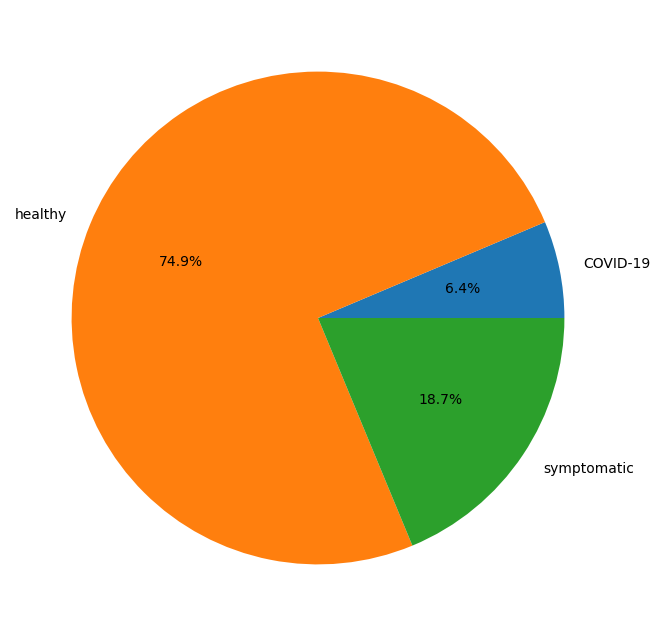

In [11]:
# status 결측치 제거 후 집계
status_df = df.dropna(subset=['status'])
status_counts = status_df.groupby('status').size()

status_counts.plot.pie(figsize=(8, 8), autopct='%1.1f%%')

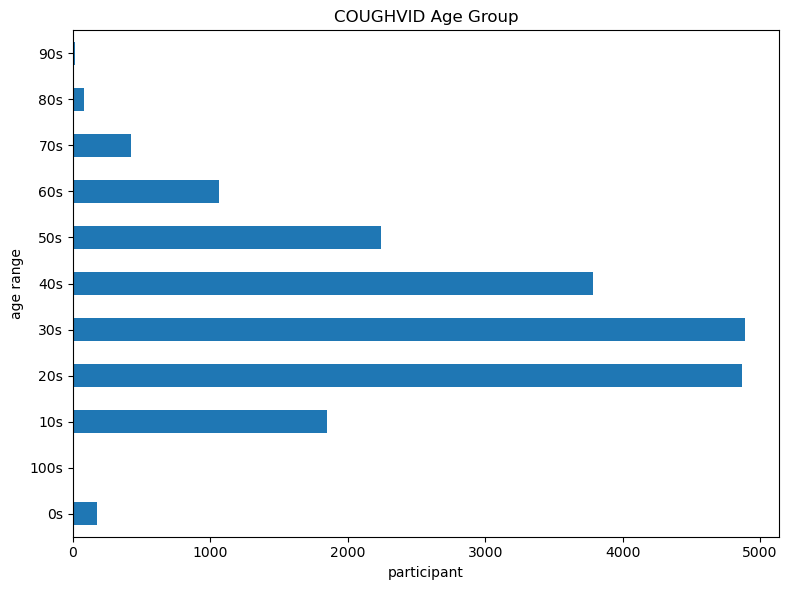

In [19]:
# age 결측치 제거 후 집계
import matplotlib.pyplot as plt

age_df = df.dropna(subset=['age'])

# 나이 10년 단위로 묶기
age_df = age_df.copy()
age_df['age_group'] = (age_df['age'] // 10*10).astype(int).astype(str) + "s"

# 집계
age_counts = age_df.groupby('age_group').size()

# 그래프
age_counts.plot.barh(figsize=(8, 6))
plt.xlabel('participant') # 참여자 수
plt.ylabel('age range') # 나이대
plt.title('COUGHVID Age Group') # 나이대별 참여자 분포
plt.tight_layout()
plt.show()

<Axes: xlabel='gender'>

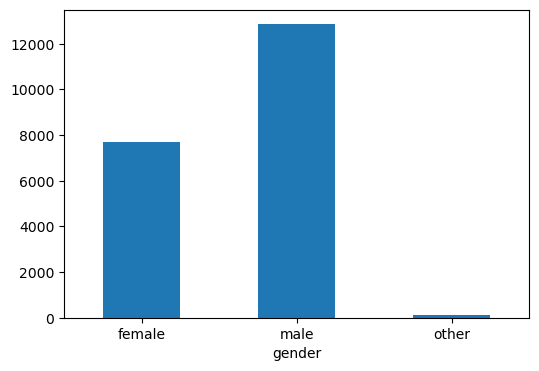

In [20]:
# gender 결측치 제거 후 집계
gender_df = df.dropna(subset=['gender'])
gender_counts = gender_df.groupby('gender').size()

gender_counts.plot.bar(figsize=(6, 4), rot=0)

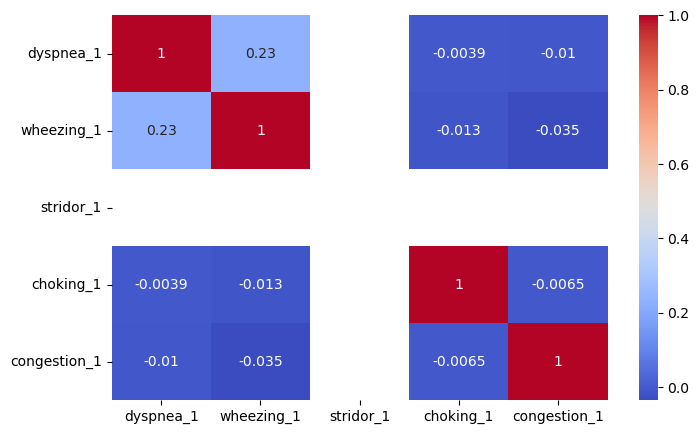

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 증상 컬럼 선택 (결측 적은 것 기준)
symptom_cols = ['respiratory_condition', 'fever_muscle_pain']
expert_cols  = ['dyspnea_1', 'wheezing_1', 'stridor_1', 'choking_1', 'congestion_1']

# 전문가 라벨 있는 행만
heatmap_df = df.dropna(subset=expert_cols)[expert_cols]

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_df.corr(), annot=True, cmap='coolwarm')
plt.show()

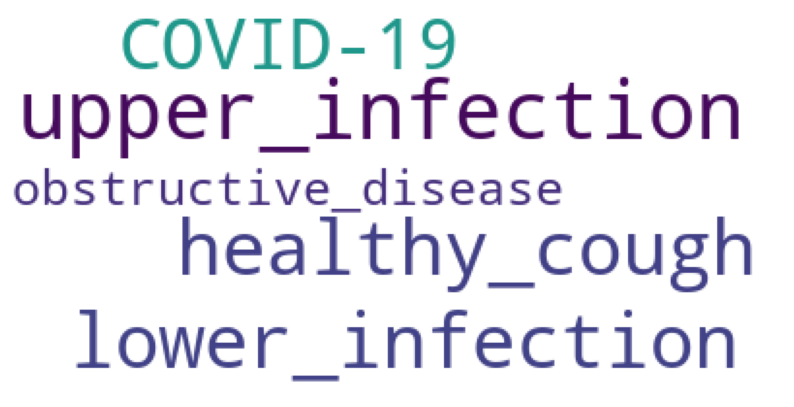

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# diagnosis_1~4 에서 값 있는 것만 모아서 하나로 합치기
diag_cols = ['diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4']
diag_series = df[diag_cols].stack().dropna()

# 빈도 딕셔너리로 변환
diag_counts = diag_series.groupby(diag_series).size().to_dict()

wordcloud = WordCloud(background_color='white').generate_from_frequencies(diag_counts)

plt.rcParams['figure.figsize'] = (10, 10)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()